# Shallow MLP Neural Network for Cycling Safety Event Classification

**Perceptrón Multicapa (MLP) con Feature Engineering para detección de anomalías ciclistas**

This notebook implements a shallow neural network (Multi-Layer Perceptron) approach to classify cycling safety events into three severity-based categories:
- **normal** (0): Regular riding
- **bache** (1): Bump / pothole event
- **severo** (2): Severe event (hard braking, swerve, or fall)

Unlike the CNN approach (which receives raw 128-sample windows), this MLP receives **hand-crafted statistical features** extracted from each window — the classic HAR feature engineering pipeline.

## BLOQUE 0 — Instalación de dependencias

## BLOQUE 1 — Librerías y configuración global

In [69]:
import os
import re
import glob as glob_mod
from pathlib import Path
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

LABELS_3 = {0: "normal", 1: "bache", 2: "severo"}
IMU_COLS = ["ax", "ay", "az", "gx", "gy", "gz"]

WIN_LEN = 128
STRIDE  = 64
TARGET_HZ = 50

# ── Dataset configuration ──
# Bike&Safe uses linear acceleration (no gravity, a_mag ≈ 4.6 while cycling),
# while Sensor Logger totalAcceleration includes gravity (a_mag ≈ 9.8).
# Keep False to train exclusively with Sensor Logger data.
USE_BIKESAFE = False

# Sensor Logger acceleration mode:
#   "linear" → accelerometer_x/y/z (gravity removed; compatible with Bike&Safe)
#   "total"  → totalAcceleration_x/y/z (gravity included)
# "linear" is recommended: anomalies show as deviations from ~0, not ~9.8.
SENSOR_LOGGER_ACC_MODE = "linear"

IN_COLAB = True
if IN_COLAB:
    BIKESAFE_DIR = Path("/content/data")
    OWN_DATA_DIR = Path("/content/own_data")
    OUT_DIR      = Path("/content/processed_mlp")
else:
    NOTEBOOK_DIR = Path(".").resolve()
    BIKESAFE_DIR = NOTEBOOK_DIR / "bikesafe_data"
    OWN_DATA_DIR = NOTEBOOK_DIR / "data"
    OUT_DIR      = NOTEBOOK_DIR / "processed_mlp"

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"USE_BIKESAFE           : {USE_BIKESAFE}")
print(f"SENSOR_LOGGER_ACC_MODE : {SENSOR_LOGGER_ACC_MODE}")
print(f"Bike&Safe dir : {BIKESAFE_DIR}")
print(f"Own data dir  : {OWN_DATA_DIR}")
print(f"Output dir    : {OUT_DIR}")

USE_BIKESAFE           : False
SENSOR_LOGGER_ACC_MODE : linear
Bike&Safe dir : /content/data
Own data dir  : /content/own_data
Output dir    : /content/processed_mlp


## BLOQUE 2 — Descarga del dataset Bike&Safe (Kaggle)

En Colab: descarga automática via Kaggle API.  
En local: se asume que el dataset ya fue descargado en `bikesafe_data/`.

In [70]:
if IN_COLAB and USE_BIKESAFE:
    os.environ["KAGGLE_USERNAME"] = "Andres_Vallejo1004"
    os.environ["KAGGLE_API_TOKEN"] = getpass("Enter Kaggle API Token: ")

    kaggle_dir = Path("/root/.kaggle")
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    (kaggle_dir / "kaggle.json").write_text(
        f'{{"username":"{os.environ["KAGGLE_USERNAME"]}","key":"{os.environ["KAGGLE_API_TOKEN"]}"}}'
    )
    os.chmod(str(kaggle_dir / "kaggle.json"), 0o600)

    BIKESAFE_DIR.mkdir(parents=True, exist_ok=True)
    os.system(f"kaggle datasets download -d shashwatwork/cyclist-accident-prevention-dataset -p {BIKESAFE_DIR} --unzip")
    print("Bike&Safe descargado.")
elif not USE_BIKESAFE:
    print("Bike&Safe deshabilitado (USE_BIKESAFE = False). Solo se usarán datos propios.")
else:
    if BIKESAFE_DIR.exists():
        print(f"Bike&Safe encontrado en {BIKESAFE_DIR}")
    else:
        print(f"AVISO: {BIKESAFE_DIR} no existe. Descarga manualmente el dataset o ejecuta en Colab.")

Bike&Safe deshabilitado (USE_BIKESAFE = False). Solo se usarán datos propios.


## BLOQUE 3 — Carga de datos Bike&Safe

Reutiliza la misma lógica del notebook CNN: indexa las rutas/laps, lee CSVs separados de acelerómetro y giroscopio, y los fusiona por timestamp.

In [71]:
def build_index(data_dir: Path) -> pd.DataFrame:
    rows = []
    if not data_dir.exists():
        return pd.DataFrame(columns=["route", "lap", "acc_path", "gyro_path", "gps_path", "mag_path"])
    for route_dir in sorted([p for p in data_dir.iterdir() if p.is_dir()]):
        route = route_dir.name
        for lap_dir in sorted([p for p in route_dir.iterdir() if p.is_dir()]):
            lap = lap_dir.name
            files = [f for f in lap_dir.iterdir() if f.is_file()]
            names = {f.name.lower(): f for f in files}

            def pick_any(patterns):
                for name, path in names.items():
                    for pat in patterns:
                        if re.search(pat, name):
                            return path
                return None

            rows.append({
                "route": route, "lap": lap,
                "acc_path":  str(pick_any([r"accelerometer"])) if pick_any([r"accelerometer"]) else None,
                "gyro_path": str(pick_any([r"gyroscope"]))     if pick_any([r"gyroscope"])     else None,
                "gps_path":  str(pick_any([r"_gps_", r"gps"]))if pick_any([r"_gps_", r"gps"])else None,
                "mag_path":  str(pick_any([r"magnetometer"]))  if pick_any([r"magnetometer"])  else None,
            })
    return pd.DataFrame(rows)


def smart_read_raw(path: str) -> pd.DataFrame:
    p = Path(path)
    if str(p).endswith(".csv.csv"):
        p2 = Path(str(p)[:-4])
        if p2.exists():
            p = p2
    for sep in [";", ",", "\t", "|"]:
        try:
            df = pd.read_csv(p, sep=sep, header=None, engine="python")
            if df.shape[1] > 1:
                return df
        except Exception:
            pass
    return pd.read_csv(p, header=None, engine="python")


def load_sensor_xyz(path: str, prefix: str) -> pd.DataFrame:
    df = smart_read_raw(path)
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(axis=1, how="all")
    ts_col = df.columns[0]
    df = df.dropna(subset=[ts_col]).copy()
    df = df.rename(columns={ts_col: "timestamp"})
    cols = list(df.columns)
    if len(cols) >= 5:
        xcol, ycol, zcol = cols[2], cols[3], cols[4]
    elif len(cols) >= 4:
        xcol, ycol, zcol = cols[1], cols[2], cols[3]
    else:
        raise ValueError(f"Muy pocas columnas ({len(cols)}): {path}")
    df = df.rename(columns={xcol: f"{prefix}x", ycol: f"{prefix}y", zcol: f"{prefix}z"})
    out = df[["timestamp", f"{prefix}x", f"{prefix}y", f"{prefix}z"]].dropna()
    return out.sort_values("timestamp").reset_index(drop=True)


def load_lap_imu(row: pd.Series) -> pd.DataFrame:
    acc  = load_sensor_xyz(row["acc_path"],  "a")
    gyro = load_sensor_xyz(row["gyro_path"], "g")
    acc["timestamp"]  = acc["timestamp"].astype(np.float64)
    gyro["timestamp"] = gyro["timestamp"].astype(np.float64)
    imu = pd.merge_asof(
        acc.sort_values("timestamp"),
        gyro.sort_values("timestamp"),
        on="timestamp", direction="nearest"
    ).dropna()
    imu["route"]  = row["route"]
    imu["lap"]    = row["lap"]
    imu["source"] = "bikesafe"
    return imu[["timestamp"] + IMU_COLS + ["route", "lap", "source"]]


if USE_BIKESAFE:
    bikesafe_idx = build_index(BIKESAFE_DIR)
    print(f"Bike&Safe: {len(bikesafe_idx)} laps encontrados")
    if len(bikesafe_idx):
        display(bikesafe_idx.head())
else:
    bikesafe_idx = pd.DataFrame(columns=["route", "lap", "acc_path", "gyro_path", "gps_path", "mag_path"])
    print("Bike&Safe deshabilitado.")

Bike&Safe deshabilitado.


In [72]:
bikesafe_imu_list = []
for i, row in bikesafe_idx.iterrows():
    try:
        imu_lap = load_lap_imu(row)
        bikesafe_imu_list.append(imu_lap)
        print(f"  Lap {row['route']}/{row['lap']}: {len(imu_lap)} muestras")
    except Exception as e:
        print(f"  ERROR en {row['route']}/{row['lap']}: {e}")

if bikesafe_imu_list:
    bikesafe_imu = pd.concat(bikesafe_imu_list, ignore_index=True)
    print(f"\nBike&Safe total: {len(bikesafe_imu)} muestras IMU")
else:
    bikesafe_imu = pd.DataFrame(columns=["timestamp"] + IMU_COLS + ["route", "lap", "source"])
    print("No se cargaron datos de Bike&Safe (dataset no disponible).")

No se cargaron datos de Bike&Safe (dataset no disponible).


## BLOQUE 4 — Carga de datos propios (Sensor Logger)

Los archivos CSV de Sensor Logger combinan todos los sensores en un solo archivo con muestreo sparse (~100 Hz).

**Modos de aceleración** (controlado por `SENSOR_LOGGER_ACC_MODE`):
- `"linear"` → usa `accelerometer_x/y/z` (aceleración lineal, sin gravedad). Baseline ~0 m/s². **Recomendado** para detección de anomalías: las desviaciones desde cero indican directamente eventos de aceleración.
- `"total"` → usa `totalAcceleration_x/y/z` (aceleración cruda, con gravedad). Baseline ~9.8 m/s².
- `"linear_from_raw"` → calcula `totalAcceleration - gravity` como fallback.

**Preprocesamiento:**
1. Se usa `gyroscope_x/y/z` directamente
2. Se interpolan los NaN (forward-fill + backward-fill + interpolación lineal)
3. Se resamplea de ~100 Hz a ~50 Hz

**Nota sobre compatibilidad con Bike&Safe:** El dataset Bike&Safe reporta magnitudes de aceleración ~4.6 m/s², lo cual no corresponde ni a aceleración cruda (~9.8) ni a aceleración lineal (~0). Esto indica un formato o unidad no estándar. Se recomienda usar `USE_BIKESAFE = False` y entrenar exclusivamente con datos propios.

In [73]:
def load_sensor_logger_csv(csv_path: Path, target_hz: int = 50,
                           acc_mode: str = "linear") -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    has_linear   = all(c in df.columns for c in
                       ["accelerometer_x", "accelerometer_y", "accelerometer_z"])
    has_total    = all(c in df.columns for c in
                       ["totalAcceleration_x", "totalAcceleration_y", "totalAcceleration_z"])
    has_gravity  = all(c in df.columns for c in
                       ["gravity_x", "gravity_y", "gravity_z"])

    if acc_mode == "linear" and has_linear:
        df["ax"] = df["accelerometer_x"]
        df["ay"] = df["accelerometer_y"]
        df["az"] = df["accelerometer_z"]
    elif acc_mode == "total" and has_total:
        df["ax"] = df["totalAcceleration_x"]
        df["ay"] = df["totalAcceleration_y"]
        df["az"] = df["totalAcceleration_z"]
    elif acc_mode == "linear_from_raw" and has_total and has_gravity:
        df["ax"] = df["totalAcceleration_x"] - df["gravity_x"]
        df["ay"] = df["totalAcceleration_y"] - df["gravity_y"]
        df["az"] = df["totalAcceleration_z"] - df["gravity_z"]
    elif has_linear:
        df["ax"] = df["accelerometer_x"]
        df["ay"] = df["accelerometer_y"]
        df["az"] = df["accelerometer_z"]
    else:
        raise ValueError(f"No se encontraron columnas de aceleración compatibles en {csv_path.name}")

    gyro_cols = ["gyroscope_x", "gyroscope_y", "gyroscope_z"]
    if not all(c in df.columns for c in gyro_cols):
        raise ValueError(f"No se encontraron columnas de giroscopio en {csv_path.name}")
    df["gx"] = df["gyroscope_x"]
    df["gy"] = df["gyroscope_y"]
    df["gz"] = df["gyroscope_z"]

    df["timestamp"] = df["seconds_elapsed"].astype(float)
    keep = ["timestamp"] + IMU_COLS
    df = df[keep].copy()

    df = df.sort_values("timestamp").reset_index(drop=True)
    df[IMU_COLS] = df[IMU_COLS].ffill().bfill()
    df[IMU_COLS] = df[IMU_COLS].interpolate(method="linear")
    df = df.dropna(subset=IMU_COLS)

    if len(df) < 2:
        return df

    dt_median = df["timestamp"].diff().median()
    source_hz = round(1.0 / dt_median) if dt_median > 0 else target_hz
    step = max(1, round(source_hz / target_hz))
    if step > 1:
        df = df.iloc[::step].reset_index(drop=True)

    return df


own_csv_files = sorted(OWN_DATA_DIR.glob("*.csv")) if OWN_DATA_DIR.exists() else []
print(f"Archivos Sensor Logger encontrados: {len(own_csv_files)}")

own_imu_list = []
for csv_path in own_csv_files:
    try:
        imu_sl = load_sensor_logger_csv(csv_path, target_hz=TARGET_HZ,
                                           acc_mode=SENSOR_LOGGER_ACC_MODE)
        ride_name = csv_path.stem[:30]
        imu_sl["route"] = ride_name
        imu_sl["lap"]   = "ride"
        imu_sl["source"] = "sensor_logger"
        own_imu_list.append(imu_sl)
        print(f"  {csv_path.name}: {len(imu_sl)} muestras (post-resample)")
    except Exception as e:
        print(f"  ERROR {csv_path.name}: {e}")

if own_imu_list:
    own_imu = pd.concat(own_imu_list, ignore_index=True)
    print(f"\nDatos propios total: {len(own_imu)} muestras IMU")
else:
    own_imu = pd.DataFrame(columns=["timestamp"] + IMU_COLS + ["route", "lap", "source"])
    print("No se cargaron datos propios.")

Archivos Sensor Logger encontrados: 6


/tmp/ipykernel_4896/1932663686.py:3: DtypeWarning: Columns (0: annotation_text) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


  48-01-2026-03-04_18-56-03-3b9d326513804af99d95f251e102bdb7.csv: 37763 muestras (post-resample)
  Interior_154-2026-02-24_19-25-18-3b9d326513804af99d95f251e102bdb7.csv: 38539 muestras (post-resample)
  Interior_154-2026-03-17_15-04-01-3b9d326513804af99d95f251e102bdb7.csv: 50919 muestras (post-resample)


/tmp/ipykernel_4896/1932663686.py:3: DtypeWarning: Columns (0: annotation_text) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


  _39A-33-2026-03-12_15-13-37-3b9d326513804af99d95f251e102bdb7.csv: 46841 muestras (post-resample)


/tmp/ipykernel_4896/1932663686.py:3: DtypeWarning: Columns (0: annotation_text) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


  _58N-19-2026-02-25_19-29-52-3b9d326513804af99d95f251e102bdb7.csv: 59581 muestras (post-resample)
  _58N-19-2026-02-28_15-37-37-3b9d326513804af99d95f251e102bdb7.csv: 40503 muestras (post-resample)

Datos propios total: 274146 muestras IMU


/tmp/ipykernel_4896/1932663686.py:3: DtypeWarning: Columns (0: annotation_text) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


## BLOQUE 5 — Unificación de datasets

In [74]:
all_imu = pd.concat([bikesafe_imu, own_imu], ignore_index=True)

print(f"Dataset unificado: {len(all_imu)} muestras")
print(f"\nMuestras por fuente:")
print(all_imu["source"].value_counts())
print(f"\nRutas/rides:")
print(all_imu.groupby("source")["route"].nunique())

Dataset unificado: 274146 muestras

Muestras por fuente:
source
sensor_logger    274146
Name: count, dtype: int64

Rutas/rides:
source
sensor_logger    6
Name: route, dtype: int64


---
# DATA PRE-PROCESSING AND EXPLORATORY DATA ANALYSIS
---

## BLOQUE 6 — Estadísticas básicas y calidad de los datos

In [75]:
print("="*60)
print("ESTADÍSTICAS BÁSICAS POR FUENTE DE DATOS")
print("="*60)

for source_name, group in all_imu.groupby("source"):
    print(f"\n--- {source_name.upper()} ---")
    print(f"Muestras: {len(group):,}")
    print(f"NaN por columna:")
    print(group[IMU_COLS].isna().sum())
    print(f"\nEstadísticas descriptivas:")
    display(group[IMU_COLS].describe().round(4))

ESTADÍSTICAS BÁSICAS POR FUENTE DE DATOS

--- SENSOR_LOGGER ---
Muestras: 274,146
NaN por columna:
ax    0
ay    0
az    0
gx    0
gy    0
gz    0
dtype: int64

Estadísticas descriptivas:


,ax,ay,az,gx,gy,gz
count,274146.000,274146.0000,274146.0000,274146.0000,274146.0000,274146.0000
unique,198689.000,196975.0000,197536.0000,9932.0000,15776.0000,13521.0000
top,-0.379,0.2843,2.5124,-0.0708,-0.2477,0.0765
freq,31339.000,31339.0000,31339.0000,42391.0000,42358.0000,42420.0000


## BLOQUE 7 — Distribuciones de sensores: comparación entre datasets

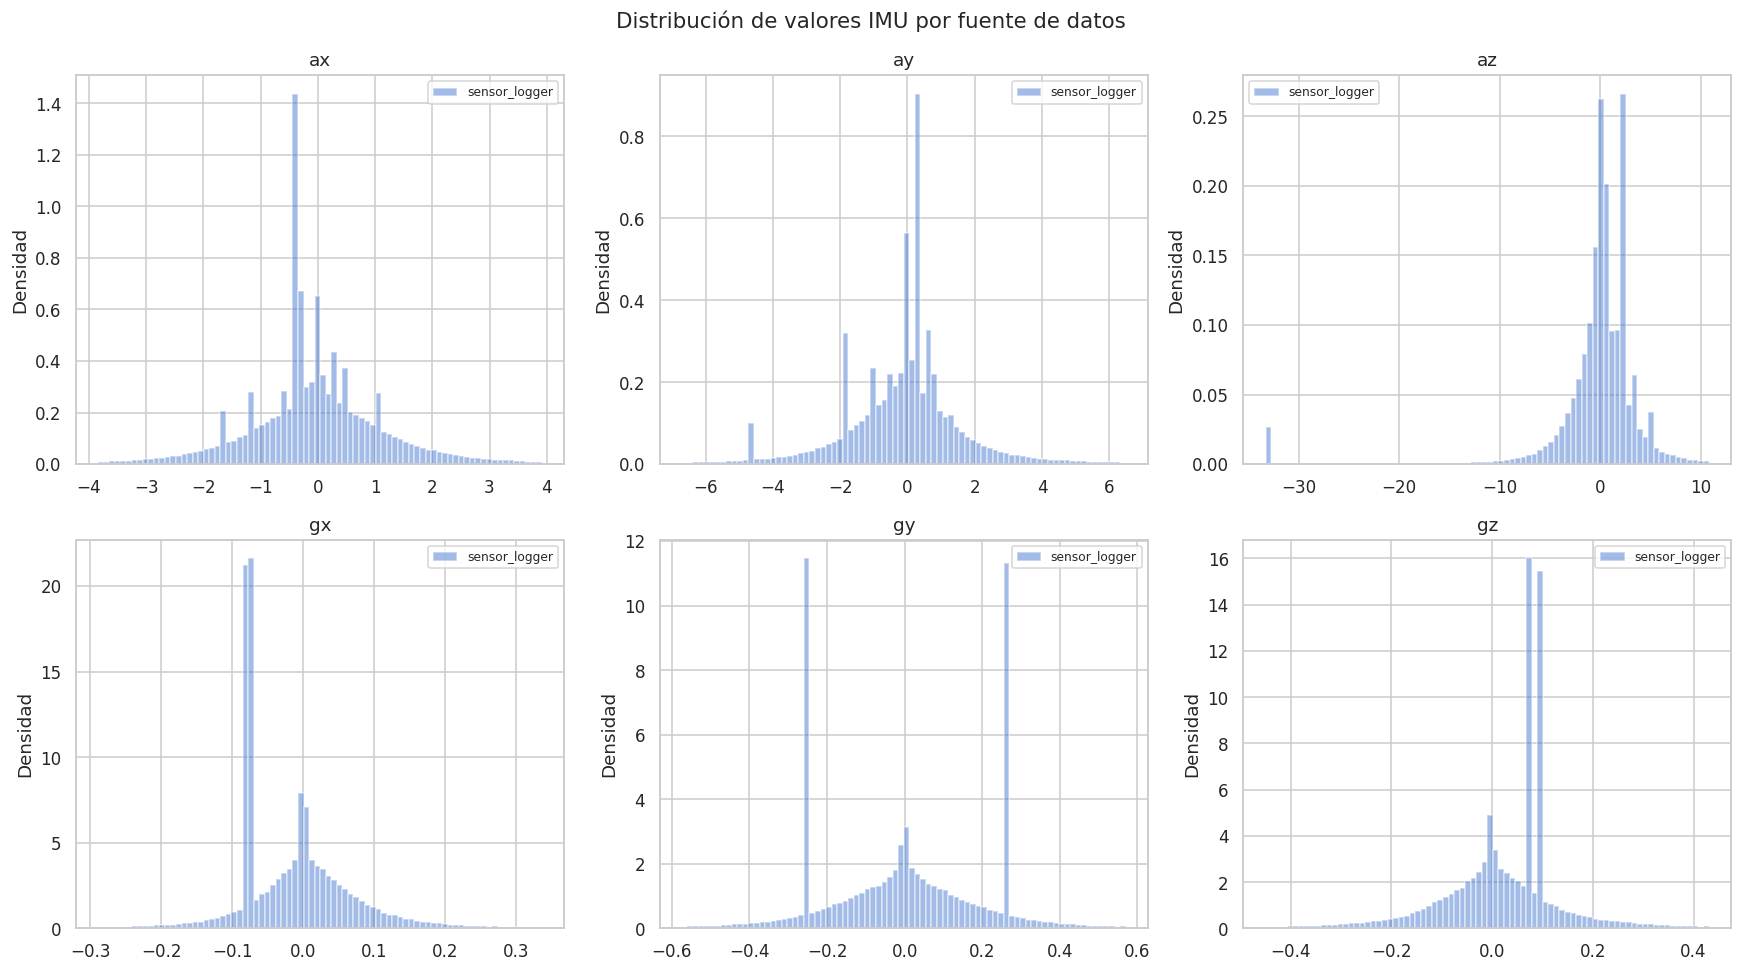

In [76]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distribución de valores IMU por fuente de datos", fontsize=14)

for i, col in enumerate(IMU_COLS):
    ax = axes[i // 3, i % 3]
    for source_name, group in all_imu.groupby("source"):
        vals = group[col].dropna()
        p1, p99 = vals.quantile(0.01), vals.quantile(0.99)
        vals_clipped = vals[(vals >= p1) & (vals <= p99)]
        ax.hist(vals_clipped, bins=80, alpha=0.5, density=True, label=source_name)
    ax.set_title(col)
    ax.legend(fontsize=8)
    ax.set_ylabel("Densidad")

plt.tight_layout()
plt.show()

## BLOQUE 8 — Magnitud de aceleración y giroscopio

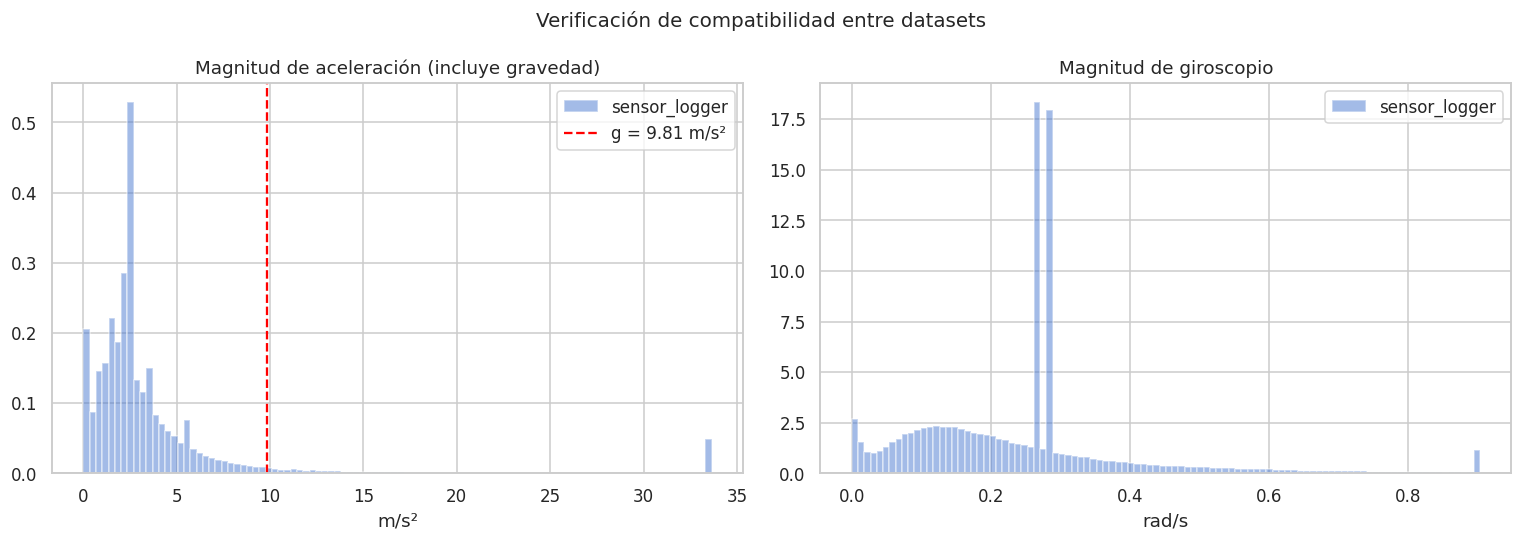


Magnitud de aceleración en reposo (mediana por fuente):
  Si ambos valores están cerca de 9.81, la armonización es correcta.
  sensor_logger: 2.557 m/s²


In [77]:
for col in IMU_COLS:
    all_imu[col] = pd.to_numeric(all_imu[col], errors='coerce')
all_imu.dropna(subset=IMU_COLS, inplace=True)

all_imu["a_mag"] = np.sqrt(all_imu["ax"]**2 + all_imu["ay"]**2 + all_imu["az"]**2)
all_imu["g_mag"] = np.sqrt(all_imu["gx"]**2 + all_imu["gy"]**2 + all_imu["gz"]**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for source_name, group in all_imu.groupby("source"):
    a_clip = group["a_mag"].clip(upper=group["a_mag"].quantile(0.99))
    axes[0].hist(a_clip, bins=100, alpha=0.5, density=True, label=source_name)
axes[0].axvline(9.81, color="red", ls="--", lw=1.5, label="g = 9.81 m/s²")
axes[0].set_title("Magnitud de aceleración (incluye gravedad)")
axes[0].set_xlabel("m/s²")
axes[0].legend()

for source_name, group in all_imu.groupby("source"):
    g_clip = group["g_mag"].clip(upper=group["g_mag"].quantile(0.99))
    axes[1].hist(g_clip, bins=100, alpha=0.5, density=True, label=source_name)
axes[1].set_title("Magnitud de giroscopio")
axes[1].set_xlabel("rad/s")
axes[1].legend()

plt.suptitle("Verificación de compatibilidad entre datasets", fontsize=13)
plt.tight_layout()
plt.show()

print("\nMagnitud de aceleración en reposo (mediana por fuente):")
print("  Si ambos valores están cerca de 9.81, la armonización es correcta.")
for source_name, group in all_imu.groupby("source"):
    print(f"  {source_name}: {group['a_mag'].median():.3f} m/s²")

## BLOQUE 9 — Series temporales de ejemplo

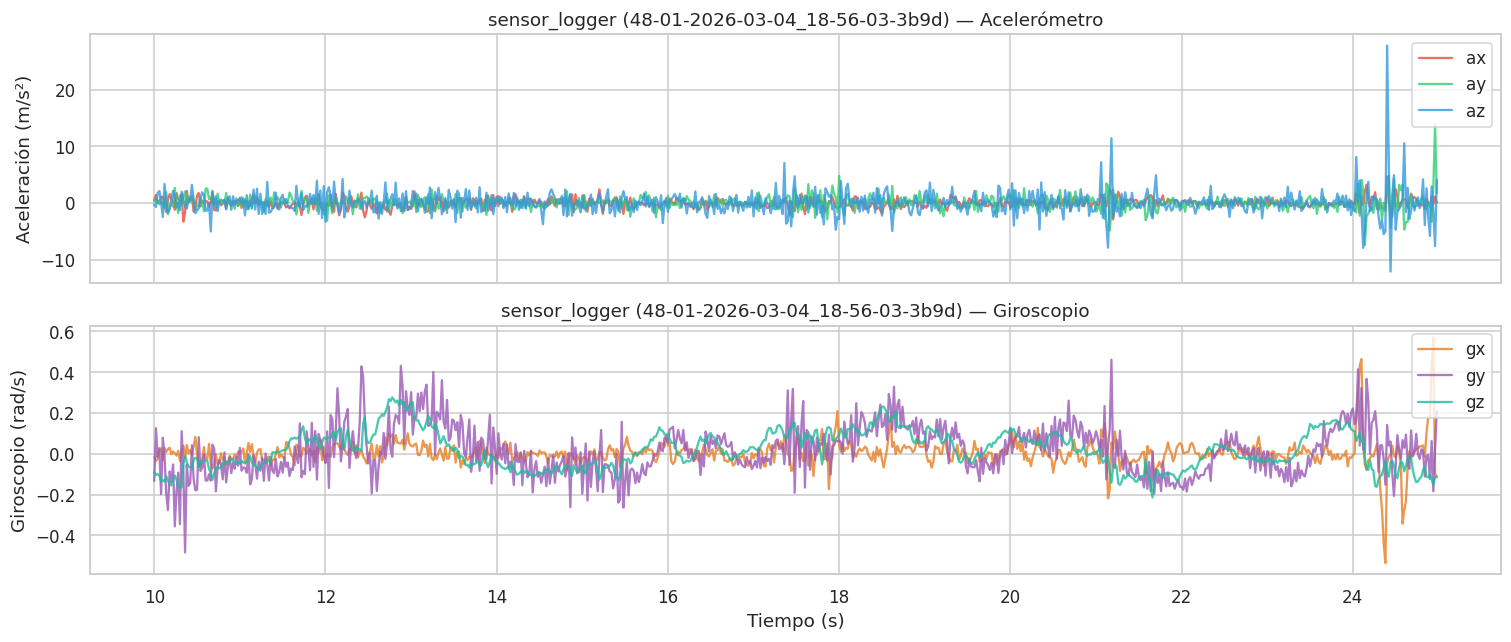

In [78]:
def plot_ride_segment(imu_df, source_label, start_sec=10, duration_sec=15):
    mask = (imu_df["timestamp"] >= start_sec) & (imu_df["timestamp"] < start_sec + duration_sec)
    segment = imu_df[mask]
    if len(segment) < 10:
        print(f"  Segmento insuficiente para {source_label}")
        return

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    t = segment["timestamp"].values

    for col, color in zip(["ax", "ay", "az"], ["#e74c3c", "#2ecc71", "#3498db"]):
        axes[0].plot(t, segment[col].values, label=col, alpha=0.8, color=color)
    axes[0].set_ylabel("Aceleración (m/s²)")
    axes[0].legend(loc="upper right")
    axes[0].set_title(f"{source_label} — Acelerómetro")

    for col, color in zip(["gx", "gy", "gz"], ["#e67e22", "#9b59b6", "#1abc9c"]):
        axes[1].plot(t, segment[col].values, label=col, alpha=0.8, color=color)
    axes[1].set_ylabel("Giroscopio (rad/s)")
    axes[1].set_xlabel("Tiempo (s)")
    axes[1].legend(loc="upper right")
    axes[1].set_title(f"{source_label} — Giroscopio")

    plt.tight_layout()
    plt.show()


for source_name, group in all_imu.groupby("source"):
    first_route = group["route"].iloc[0]
    ride = group[group["route"] == first_route]
    plot_ride_segment(ride, f"{source_name} ({first_route})")

## BLOQUE 10 — Matriz de correlación entre canales IMU

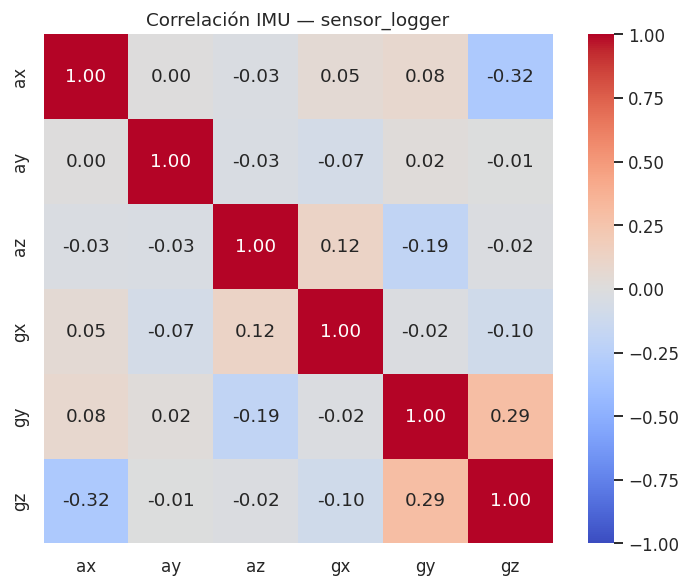

In [79]:
sources = all_imu["source"].unique()
n_sources = len(sources)
fig, axes = plt.subplots(1, n_sources, figsize=(7 * n_sources, 5.5))
if n_sources == 1:
    axes = [axes]

for ax, source_name in zip(axes, sources):
    corr = all_imu[all_imu["source"] == source_name][IMU_COLS].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                vmin=-1, vmax=1, ax=ax, square=True)
    ax.set_title(f"Correlación IMU — {source_name}")

plt.tight_layout()
plt.show()

---
## BLOQUE 11 — Ventaneo (windowing)

Cada ventana de 128 muestras a 50 Hz cubre **~2.56 segundos** de recorrido, tiempo suficiente para capturar un evento completo (bache, frenado, etc). El stride de 64 genera un solapamiento del 50%.

In [80]:
def build_windows(imu: pd.DataFrame, win_len=WIN_LEN, stride=STRIDE):
    X = imu[IMU_COLS].values.astype(np.float32)
    n = X.shape[0]
    windows = []
    for s in range(0, n - win_len + 1, stride):
        windows.append(X[s : s + win_len])
    if not windows:
        return np.empty((0, win_len, len(IMU_COLS)), dtype=np.float32)
    return np.stack(windows, axis=0)


all_windows = []
meta_list   = []

for source_name, source_group in all_imu.groupby("source"):
    for route_name, route_group in source_group.groupby("route"):
        for lap_name, lap_group in route_group.groupby("lap"):
            wins = build_windows(lap_group)
            all_windows.append(wins)
            for _ in range(len(wins)):
                meta_list.append({
                    "source": source_name,
                    "route":  route_name,
                    "lap":    lap_name,
                })

X_all = np.concatenate(all_windows, axis=0)
meta  = pd.DataFrame(meta_list)

print(f"Ventanas totales: {X_all.shape[0]}")
print(f"Forma de cada ventana: {X_all.shape[1:]}  (muestras × canales)")
print(f"\nVentanas por fuente:")
print(meta["source"].value_counts())

Ventanas totales: 4274
Forma de cada ventana: (128, 6)  (muestras × canales)

Ventanas por fuente:
source
sensor_logger    4274
Name: count, dtype: int64


## BLOQUE 12 — Feature Engineering

Para la red MLP, cada ventana de 128×6 se resume en un vector de **características estadísticas**.  
Por cada uno de los 6 canales se calculan: media, desviación estándar, mínimo, máximo, rango, RMS (energía), asimetría (skewness) y curtosis.  
Además se computan estadísticas de la magnitud de aceleración y giroscopio.

In [81]:
def extract_features(window: np.ndarray) -> dict:
    feats = {}
    for i, col in enumerate(IMU_COLS):
        v = window[:, i]
        feats[f"{col}_mean"]  = np.mean(v)
        feats[f"{col}_std"]   = np.std(v)
        feats[f"{col}_min"]   = np.min(v)
        feats[f"{col}_max"]   = np.max(v)
        feats[f"{col}_range"] = np.ptp(v)
        feats[f"{col}_rms"]   = np.sqrt(np.mean(v ** 2))
        feats[f"{col}_skew"]  = float(sp_stats.skew(v))
        feats[f"{col}_kurt"]  = float(sp_stats.kurtosis(v))
        feats[f"{col}_p05"]   = np.percentile(v, 5)
        feats[f"{col}_p95"]   = np.percentile(v, 95)

    ax, ay, az = window[:, 0], window[:, 1], window[:, 2]
    gx, gy, gz = window[:, 3], window[:, 4], window[:, 5]
    a_mag = np.sqrt(ax**2 + ay**2 + az**2)
    g_mag = np.sqrt(gx**2 + gy**2 + gz**2)

    for name, mag in [("a_mag", a_mag), ("g_mag", g_mag)]:
        feats[f"{name}_mean"]  = np.mean(mag)
        feats[f"{name}_std"]   = np.std(mag)
        feats[f"{name}_max"]   = np.max(mag)
        feats[f"{name}_range"] = np.ptp(mag)
        feats[f"{name}_rms"]   = np.sqrt(np.mean(mag ** 2))
        feats[f"{name}_p99"]   = np.percentile(mag, 99)

    return feats


print("Extrayendo características estadísticas de cada ventana...")
feat_list = [extract_features(X_all[i]) for i in range(X_all.shape[0])]
feat_df = pd.DataFrame(feat_list)

# Sanitize: skew/kurtosis can produce NaN/Inf for constant-value windows
n_bad = feat_df.isin([np.inf, -np.inf]).sum().sum() + feat_df.isna().sum().sum()
feat_df = feat_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)
print(f"Vector de características: {feat_df.shape[1]} features por ventana")
print(f"Total de ventanas: {feat_df.shape[0]}")
print(f"Valores NaN/Inf reemplazados por 0: {n_bad}")
display(feat_df.head())

Extrayendo características estadísticas de cada ventana...


/tmp/ipykernel_4896/2911098285.py:11: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feats[f"{col}_skew"]  = float(sp_stats.skew(v))
/tmp/ipykernel_4896/2911098285.py:12: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feats[f"{col}_kurt"]  = float(sp_stats.kurtosis(v))


Vector de características: 72 features por ventana
Total de ventanas: 4274
Valores NaN/Inf reemplazados por 0: 10896


,ax_mean,ax_std,ax_min,ax_max,ax_range,ax_rms,ax_skew,ax_kurt,ax_p05,ax_p95,...,a_mag_max,a_mag_range,a_mag_rms,a_mag_p99,g_mag_mean,g_mag_std,g_mag_max,g_mag_range,g_mag_rms,g_mag_p99
0,-0.131123,0.898791,-3.754683,2.214782,5.969465,0.908305,-0.378217,1.309273,-1.455826,1.273560,...,5.669157,5.669157,1.821853,4.594646,0.369978,0.149184,0.701331,0.641574,0.398923,0.646292
1,-0.037690,0.867498,-2.298884,2.214782,4.513666,0.868317,0.024247,-0.197927,-1.372149,1.413157,...,4.788548,4.345567,1.907982,4.287536,0.185877,0.104366,0.496111,0.466143,0.213173,0.437724
2,0.010235,0.903958,-2.298884,1.964431,4.263315,0.904016,-0.056001,-0.413438,-1.321792,1.480816,...,4.408356,4.223128,1.850245,3.932372,0.129102,0.065894,0.326866,0.296899,0.144946,0.281739
3,0.101988,1.040191,-2.200541,3.229288,5.429830,1.045179,0.256912,-0.154617,-1.473136,1.880161,...,4.117764,3.932536,1.895297,3.842590,0.200836,0.097535,0.496149,0.457626,0.223267,0.453343
4,0.193061,1.121972,-2.200541,3.229288,5.429830,1.138461,0.307582,-0.230489,-1.546751,2.276855,...,4.117764,3.745756,1.948058,3.793884,0.256057,0.089002,0.496801,0.386345,0.271084,0.484667


## BLOQUE 13 — Distribución de features seleccionadas

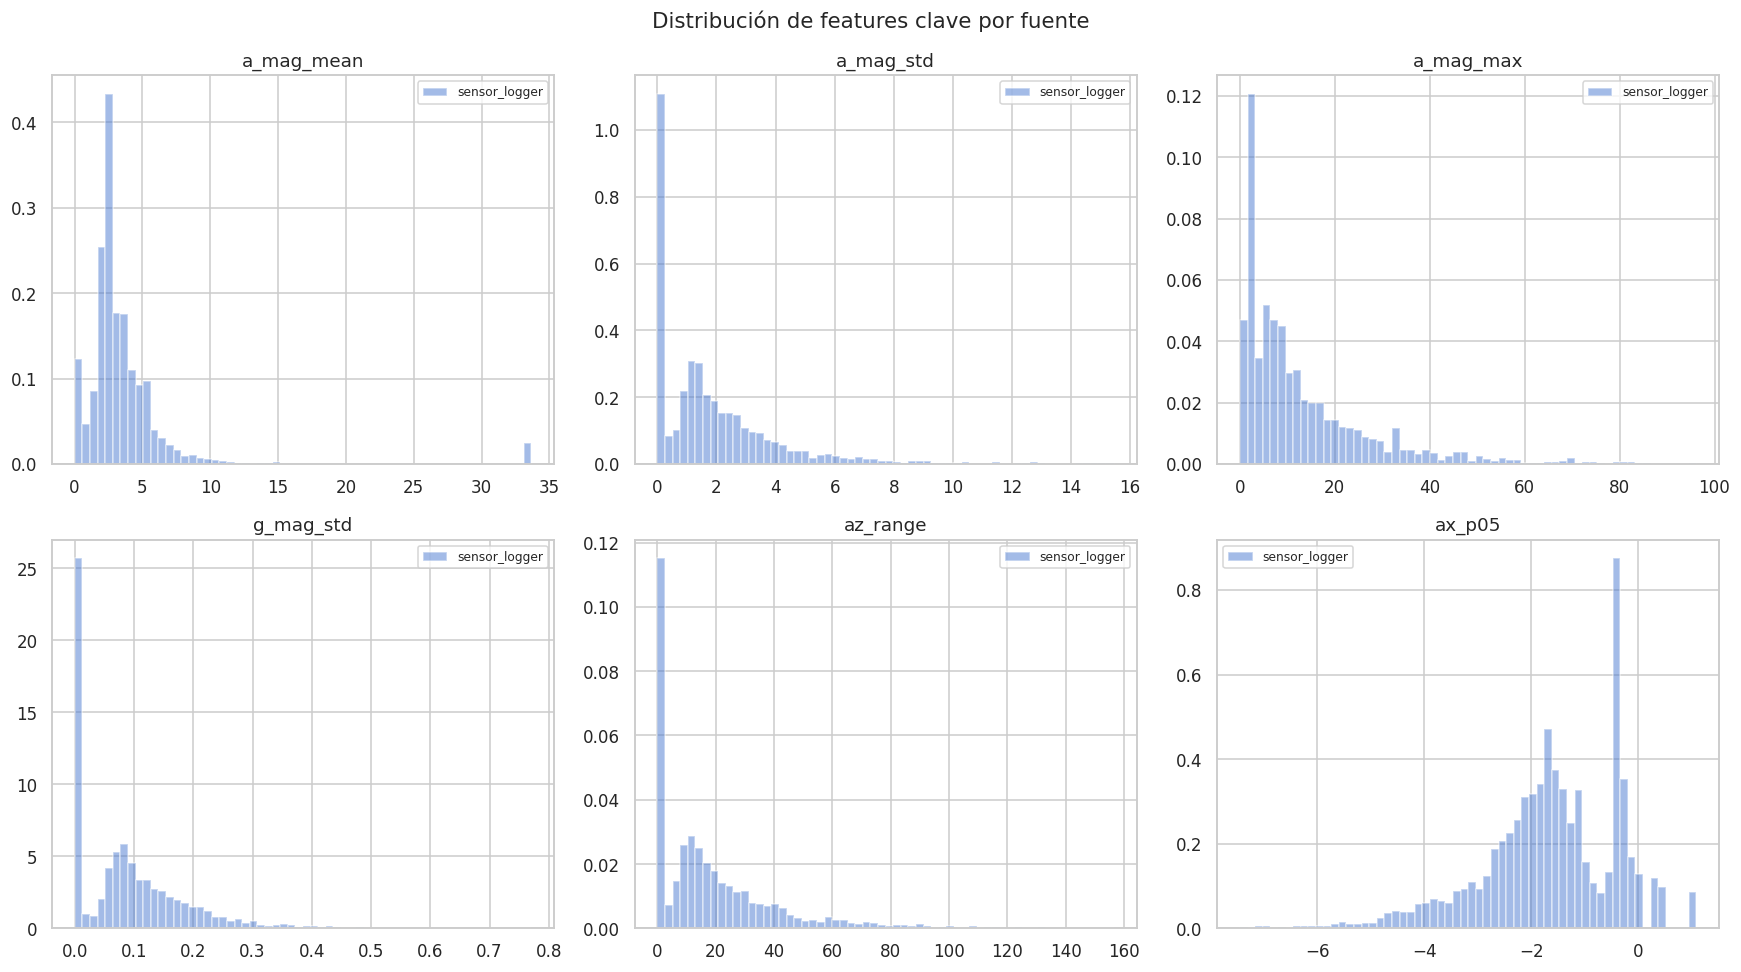

In [82]:
highlight_feats = ["a_mag_mean", "a_mag_std", "a_mag_max", "g_mag_std", "az_range", "ax_p05"]
highlight_feats = [f for f in highlight_feats if f in feat_df.columns]

combined = feat_df.copy()
combined["source"] = meta["source"].values

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distribución de features clave por fuente", fontsize=14)

for i, feat_name in enumerate(highlight_feats):
    ax = axes[i // 3, i % 3]
    for src in combined["source"].unique():
        vals = combined[combined["source"] == src][feat_name]
        ax.hist(vals, bins=60, alpha=0.5, density=True, label=src)
    ax.set_title(feat_name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## BLOQUE 14 — Etiquetado por severidad (3 clases)

Se asigna una etiqueta a cada ventana según su severity_score y bump_score, calibrados con los umbrales del conjunto de entrenamiento. La misma estrategia usada en el notebook CNN.

In [83]:
def compute_scores(feats: dict) -> tuple:
    ax_p05     = feats.get("ax_p05",     0)
    a_mag_p99  = feats.get("a_mag_p99",  0)
    g_mag_p99  = feats.get("g_mag_p99",  0)
    g_mag_std  = feats.get("g_mag_std",  0)
    az_max     = feats.get("az_max",     0)

    severity_score = abs(ax_p05) + a_mag_p99 + g_mag_p99 + g_mag_std
    bump_score     = abs(az_max)
    return float(severity_score), float(bump_score)


scores = np.array([compute_scores(feat_list[i]) for i in range(len(feat_list))])
feat_df["severity_score"] = scores[:, 0]
feat_df["bump_score"]     = scores[:, 1]

# Rates: fraction of windows labeled as each class.
# Lower values = stricter thresholds = fewer anomalies detected.
TARGET_SEVERE_RATE = 0.08
TARGET_BUMP_RATE   = 0.18

bikesafe_mask = (meta["source"] == "bikesafe").values
own_mask      = (meta["source"] == "sensor_logger").values

if USE_BIKESAFE and bikesafe_mask.any():
    train_routes = ["First route", "Second route"]
    val_routes   = ["Third route"]
    train_mask   = bikesafe_mask & meta["route"].isin(train_routes).values
    val_mask     = bikesafe_mask & meta["route"].isin(val_routes).values
    calibration_indices = np.where(train_mask)[0]
else:
    # Split by RIDES (not random windows) to prevent data leakage
    # from the 50% overlapping windows.
    own_routes = meta[own_mask]["route"].unique().tolist()
    np.random.seed(SEED)
    np.random.shuffle(own_routes)
    split_idx = max(1, int(len(own_routes) * 0.8))
    train_rides = own_routes[:split_idx]
    val_rides   = own_routes[split_idx:]

    train_mask = own_mask & meta["route"].isin(train_rides).values
    val_mask   = own_mask & meta["route"].isin(val_rides).values
    calibration_indices = np.where(train_mask)[0]
    print(f"Solo datos propios -- split por rides:")
    print(f"  Train rides ({len(train_rides)}): {train_rides}")
    print(f"  Val rides   ({len(val_rides)}):   {val_rides}")
    print(f"  Train windows: {train_mask.sum()}, Val windows: {val_mask.sum()}")

sev_th  = float(np.percentile(feat_df.loc[calibration_indices, "severity_score"], 100 * (1 - TARGET_SEVERE_RATE)))
bump_th = float(np.percentile(feat_df.loc[calibration_indices, "bump_score"],     100 * (1 - TARGET_BUMP_RATE)))

print(f"Umbrales calibrados:")
print(f"  severity_threshold = {sev_th:.4f}  (top {TARGET_SEVERE_RATE*100:.0f}%)")
print(f"  bump_threshold     = {bump_th:.4f}  (top {TARGET_BUMP_RATE*100:.0f}%)")

N = len(feat_df)
labels = np.zeros(N, dtype=np.int32)
labels[feat_df["severity_score"].values >= sev_th] = 2
labels[(labels == 0) & (feat_df["bump_score"].values >= bump_th)] = 1

meta["label_id"]   = labels
meta["label_name"] = [LABELS_3[l] for l in labels]

print(f"\nDistribución global de etiquetas:")
print(meta["label_name"].value_counts())
print(f"\nDistribución por fuente:")
print(meta.groupby("source")["label_name"].value_counts())

Solo datos propios -- split por rides:
  Train rides (4): ['48-01-2026-03-04_18-56-03-3b9d', 'Interior_154-2026-02-24_19-25-', '_58N-19-2026-02-28_15-37-37-3b', 'Interior_154-2026-03-17_15-04-']
  Val rides   (2):   ['_58N-19-2026-02-25_19-29-52-3b', '_39A-33-2026-03-12_15-13-37-3b']
  Train windows: 2615, Val windows: 1659
Umbrales calibrados:
  severity_threshold = 34.4539  (top 8%)
  bump_threshold     = 22.3262  (top 18%)

Distribución global de etiquetas:
label_name
normal    3603
bache      372
severo     299
Name: count, dtype: int64

Distribución por fuente:
source         label_name
sensor_logger  normal        3603
               bache          372
               severo         299
Name: count, dtype: int64


## BLOQUE 15 — Distribución de scores y umbrales

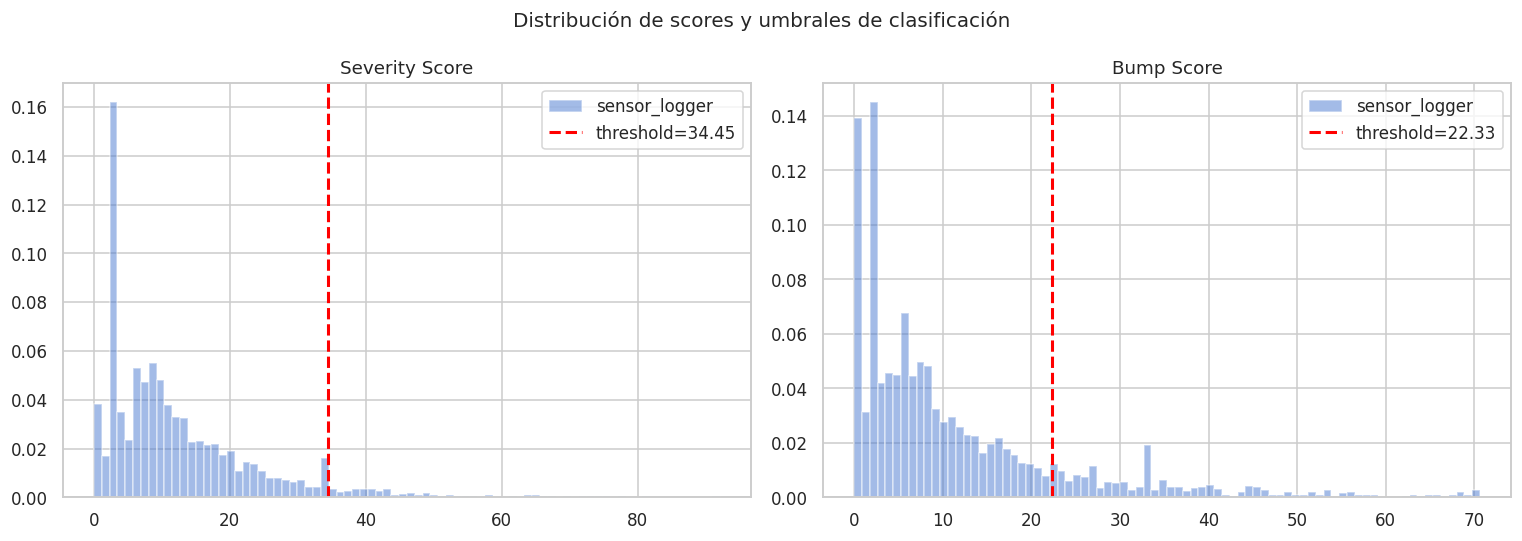

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for src in meta["source"].unique():
    mask_src = (meta["source"] == src).values
    axes[0].hist(feat_df.loc[mask_src, "severity_score"], bins=80, alpha=0.5, density=True, label=src)
axes[0].axvline(sev_th, color="red", ls="--", lw=2, label=f"threshold={sev_th:.2f}")
axes[0].set_title("Severity Score")
axes[0].legend()

for src in meta["source"].unique():
    mask_src = (meta["source"] == src).values
    axes[1].hist(feat_df.loc[mask_src, "bump_score"], bins=80, alpha=0.5, density=True, label=src)
axes[1].axvline(bump_th, color="red", ls="--", lw=2, label=f"threshold={bump_th:.2f}")
axes[1].set_title("Bump Score")
axes[1].legend()

plt.suptitle("Distribución de scores y umbrales de clasificación", fontsize=13)
plt.tight_layout()
plt.show()

## BLOQUE 16 — Split train / val / test y normalización

In [85]:
meta["split"] = "unused"
meta.loc[train_mask, "split"] = "train"
meta.loc[val_mask,   "split"] = "val"

X_feats = feat_df.drop(columns=["severity_score", "bump_score"], errors="ignore").values.astype(np.float32)

X_train_raw = X_feats[train_mask]
y_train     = labels[train_mask]
X_val_raw   = X_feats[val_mask]
y_val       = labels[val_mask]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw) if len(X_val_raw) > 0 else np.empty((0, X_train.shape[1]))

# Fix zero-variance columns: StandardScaler produces NaN when std=0
nan_cols = np.where(np.isnan(X_train).any(axis=0))[0]
if len(nan_cols) > 0:
    print(f"Columnas con varianza cero (NaN post-scaling): {len(nan_cols)} -- reemplazando con 0")
    X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
    X_val   = np.nan_to_num(X_val,   nan=0.0, posinf=0.0, neginf=0.0)

assert not np.any(np.isnan(X_train)), "X_train still contains NaN!"
assert not np.any(np.isnan(X_val)),   "X_val still contains NaN!"
print("Data sanitization check passed (no NaN/Inf in scaled features)")

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}   y_val   : {y_val.shape}")

print(f"\nDistribución de clases (train):")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {LABELS_3[u]}: {c} ({c/len(y_train)*100:.1f}%)")

print(f"\nDistribución de clases (val):")
unique_v, counts_v = np.unique(y_val, return_counts=True)
for u, c in zip(unique_v, counts_v):
    print(f"  {LABELS_3[u]}: {c} ({c/len(y_val)*100:.1f}%)")

Data sanitization check passed (no NaN/Inf in scaled features)
X_train : (2615, 72)   y_train : (2615,)
X_val   : (1659, 72)   y_val   : (1659,)

Distribución de clases (train):
  normal: 2137 (81.7%)
  bache: 240 (9.2%)
  severo: 238 (9.1%)

Distribución de clases (val):
  normal: 1466 (88.4%)
  bache: 132 (8.0%)
  severo: 61 (3.7%)


---
# PROPOSED SHALLOW NEURAL NETWORK BASED APPROACH

Se propone un **Perceptrón Multicapa (MLP)** con dos capas ocultas. A diferencia de la CNN que procesa ventanas crudas de 128×6, el MLP recibe un vector plano de características estadísticas extraídas de cada ventana.

**Arquitectura:**  
`Input(n_features) → Dense(128, ReLU) → Dropout(0.3) → Dense(64, ReLU) → Dropout(0.2) → Dense(3, Softmax)`

**Justificación:**  
- 2 capas ocultas: red superficial adecuada para features pre-calculadas
- ReLU: evita gradientes que desaparecen, eficiente computacionalmente
- Dropout: regularización para prevenir sobreajuste
- Softmax: salida probabilística para 3 clases

---

## BLOQUE 17 — Construcción del modelo MLP

In [86]:
def build_mlp(n_features: int, n_classes: int = 3) -> keras.Model:
    inp = keras.Input(shape=(n_features,))
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    return keras.Model(inp, out)


n_features = X_train.shape[1]
mlp_model = build_mlp(n_features, n_classes=3)
mlp_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,795 (69.51 KB)

 Trainable params: 17,795 (69.51 KB)

 Non-trainable params: 0 (0.00 B)

## BLOQUE 18 — Entrenamiento

In [87]:
classes_present = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes_present, y=y_train)
class_weight = dict(zip(classes_present.tolist(), weights.tolist()))
print("Class weights:", {LABELS_3[k]: f"{v:.3f}" for k, v in class_weight.items()})

LR = 1e-3
EPOCHS = 100
BATCH_SIZE = 256

mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]

history = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val) if len(X_val) > 0 else None,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1,
)

Class weights: {'normal': '0.408', 'bache': '3.632', 'severo': '3.662'}
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.4317 - loss: 1.0753 - val_accuracy: 0.7860 - val_loss: 0.6803 - learning_rate: 0.0010
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7201 - loss: 0.7271 - val_accuracy: 0.8879 - val_loss: 0.3389 - learning_rate: 0.0010
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8294 - loss: 0.5623 - val_accuracy: 0.9265 - val_loss: 0.2339 - learning_rate: 0.0010
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8654 - loss: 0.5166 - val_accuracy: 0.9373 - val_loss: 0.1959 - learning_rate: 0.0010
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8757 - loss: 0.4351 - val_accuracy: 0.9385 - val_loss: 0.1786 - learning_rate: 0.0010
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8899 - loss: 0.4123 - val_accuracy: 0.9409 - val_loss: 0.1657 - learning_rate: 0.0010
Epoch 7/100
11/1

---
# PRELIMINARY RESULTS AND PERFORMANCE EVALUATION
---

## BLOQUE 19 — Curvas de entrenamiento (loss y accuracy)

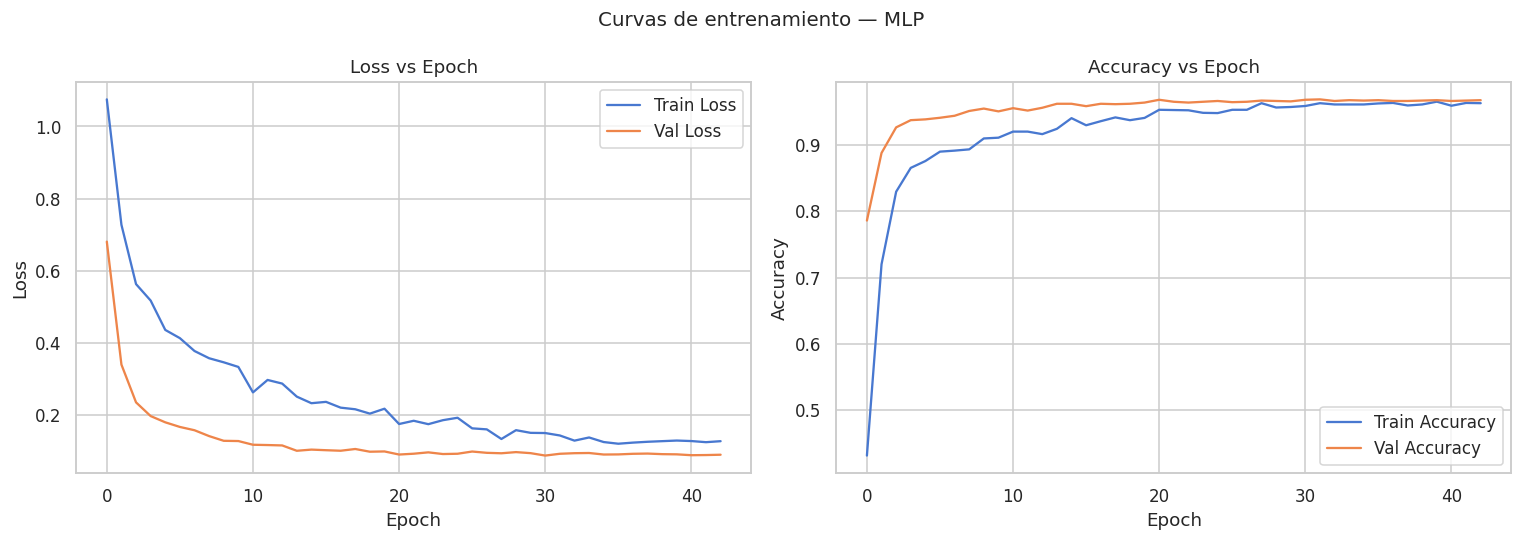


Final train loss: 0.1262
Final val loss  : 0.0886
Gap (val - train): -0.0376
✓ El modelo parece estar aprendiendo adecuadamente.


In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Train Loss")
if "val_loss" in history.history:
    axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
if "val_accuracy" in history.history:
    axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.suptitle("Curvas de entrenamiento — MLP", fontsize=13)
plt.tight_layout()
plt.show()

if "val_loss" in history.history:
    final_train_loss = history.history["loss"][-1]
    final_val_loss   = history.history["val_loss"][-1]
    gap = final_val_loss - final_train_loss
    print(f"\nFinal train loss: {final_train_loss:.4f}")
    print(f"Final val loss  : {final_val_loss:.4f}")
    print(f"Gap (val - train): {gap:.4f}")
    if gap > 0.3:
        print("⚠ Posible OVERFITTING: la pérdida de validación es significativamente mayor que la de entrenamiento.")
    elif final_train_loss > 0.8:
        print("⚠ Posible UNDERFITTING: la pérdida de entrenamiento es alta, el modelo no aprende suficiente.")
    else:
        print("✓ El modelo parece estar aprendiendo adecuadamente.")

## BLOQUE 20 — Métricas de clasificación (Validation set)


EVALUACIÓN — Validation (Sensor Logger rides)
Accuracy : 0.9681
F1 Macro : 0.8676

Classification Report:
              precision    recall  f1-score   support

      normal       1.00      0.98      0.99      1466
       bache       0.74      0.92      0.82       132
      severo       0.88      0.72      0.79        61

    accuracy                           0.97      1659
   macro avg       0.87      0.87      0.87      1659
weighted avg       0.97      0.97      0.97      1659



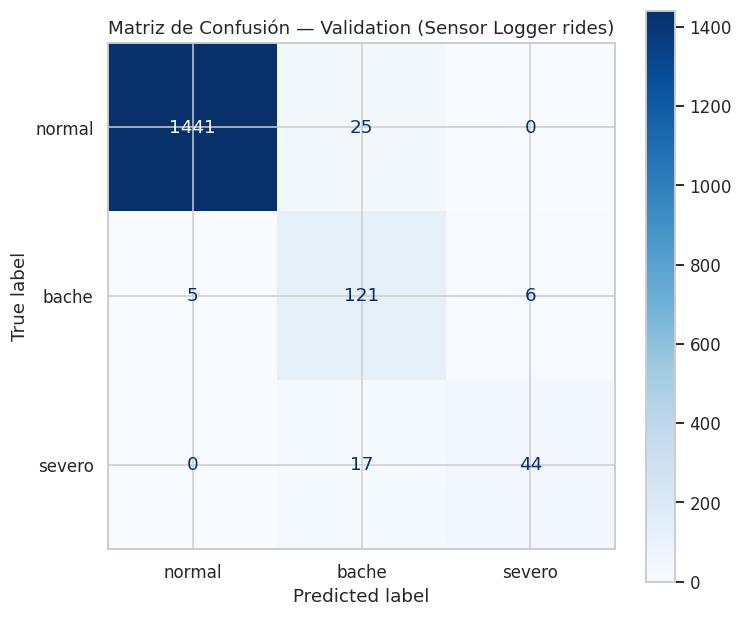

In [89]:
def evaluate_and_report(model, X, y, set_name="Validation"):
    if len(X) == 0:
        print(f"\n{set_name}: sin datos para evaluar.")
        return

    y_pred_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    acc = accuracy_score(y, y_pred)
    f1_macro = f1_score(y, y_pred, average="macro", zero_division=0)

    print(f"\n{'='*60}")
    print(f"EVALUACIÓN — {set_name}")
    print(f"{'='*60}")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Macro : {f1_macro:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(
        y, y_pred,
        target_names=[LABELS_3[i] for i in sorted(LABELS_3.keys())],
        zero_division=0
    ))

    cm = confusion_matrix(y, y_pred, labels=[0, 1, 2])
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(cm, display_labels=[LABELS_3[i] for i in [0, 1, 2]])
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Matriz de Confusión — {set_name}")
    plt.tight_layout()
    plt.show()

    return {"accuracy": acc, "f1_macro": f1_macro, "y_pred": y_pred}


val_label = "Validation (Bike&Safe - Third route)" if USE_BIKESAFE else "Validation (Sensor Logger rides)"
val_results = evaluate_and_report(mlp_model, X_val, y_val, val_label)

## BLOQUE 21 — Evaluación en Train (sanity check) y análisis de predicciones


EVALUACIÓN — Train set (sanity check)
Accuracy : 0.9721
F1 Macro : 0.9430

Classification Report:
              precision    recall  f1-score   support

      normal       1.00      0.97      0.98      2137
       bache       0.79      0.96      0.87       240
      severo       0.96      1.00      0.98       238

    accuracy                           0.97      2615
   macro avg       0.91      0.98      0.94      2615
weighted avg       0.98      0.97      0.97      2615



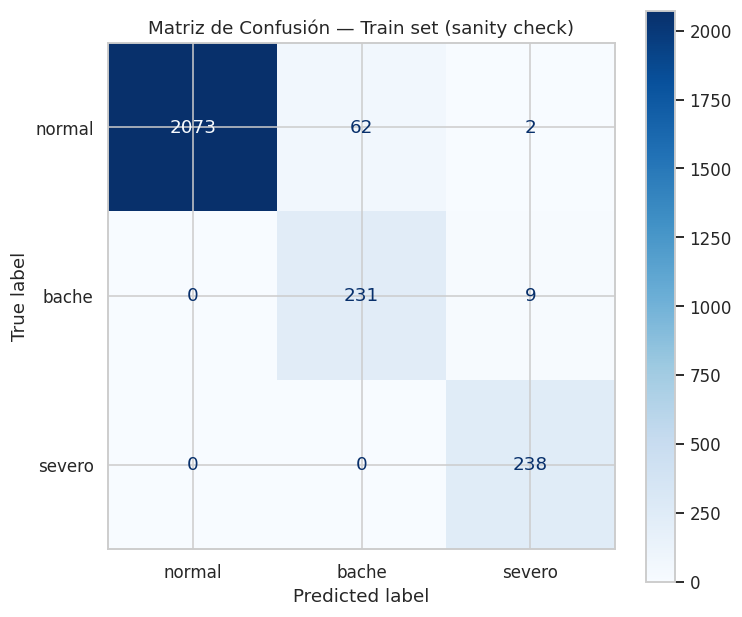


ANÁLISIS DE PREDICCIONES EN VALIDACIÓN
Predicciones del modelo:
  normal: 1446 ventanas (87.2%)
  bache: 163 ventanas (9.8%)
  severo: 50 ventanas (3.0%)

Tiempo estimado de anomalías: 273s (4.5 min)


In [90]:
train_results = evaluate_and_report(mlp_model, X_train, y_train, "Train set (sanity check)")

print("\n" + "="*60)
print("ANÁLISIS DE PREDICCIONES EN VALIDACIÓN")
print("="*60)
if val_results:
    y_val_pred = val_results["y_pred"]
    unique_pred, counts_pred = np.unique(y_val_pred, return_counts=True)
    print("Predicciones del modelo:")
    for u, c in zip(unique_pred, counts_pred):
        print(f"  {LABELS_3[u]}: {c} ventanas ({c/len(y_val_pred)*100:.1f}%)")

    n_anomalies = np.sum(y_val_pred > 0)
    total_time_anomaly = n_anomalies * (WIN_LEN / TARGET_HZ) * (STRIDE / WIN_LEN)
    print(f"\nTiempo estimado de anomalías: {total_time_anomaly:.0f}s ({total_time_anomaly/60:.1f} min)")

## BLOQUE 22 — Tabla resumen comparativa

In [91]:
summary_rows = []

if train_results:
    summary_rows.append({
        "Dataset": "Train",
        "Muestras": len(X_train),
        "Accuracy": f"{train_results['accuracy']:.4f}",
        "F1 Macro": f"{train_results['f1_macro']:.4f}",
    })

if val_results:
    val_label_short = "Bike&Safe (val)" if USE_BIKESAFE else "Sensor Logger (val 20%)"
    summary_rows.append({
        "Dataset": val_label_short,
        "Muestras": len(X_val),
        "Accuracy": f"{val_results['accuracy']:.4f}",
        "F1 Macro": f"{val_results['f1_macro']:.4f}",
    })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    print("\nResumen de rendimiento del MLP:")
    display(summary_df)
else:
    print("No hay resultados para mostrar.")


Resumen de rendimiento del MLP:


,Dataset,Muestras,Accuracy,F1 Macro
0,Train,2615,0.9721,0.9430
1,Sensor Logger (val 20%),1659,0.9681,0.8676


## BLOQUE 23 — Diagnóstico de overfitting / underfitting

In [92]:
print("DIAGNÓSTICO DEL MODELO")
print("=" * 60)

train_loss_final = history.history["loss"][-1]
train_acc_final  = history.history["accuracy"][-1]
print(f"Train Loss final   : {train_loss_final:.4f}")
print(f"Train Accuracy final: {train_acc_final:.4f}")

if "val_loss" in history.history:
    val_loss_final = history.history["val_loss"][-1]
    val_acc_final  = history.history["val_accuracy"][-1]
    print(f"Val Loss final     : {val_loss_final:.4f}")
    print(f"Val Accuracy final : {val_acc_final:.4f}")
    print()

    loss_gap = val_loss_final - train_loss_final
    acc_gap  = train_acc_final - val_acc_final

    if loss_gap > 0.3 or acc_gap > 0.10:
        print("DIAGNÓSTICO: OVERFITTING")
        print("  El modelo se ajusta demasiado al entrenamiento.")
        print("  Acciones recomendadas:")
        print("    - Aumentar Dropout")
        print("    - Reducir el número de neuronas")
        print("    - Agregar más datos de entrenamiento")
        print("    - Aplicar data augmentation")
    elif train_loss_final > 0.8 and train_acc_final < 0.65:
        print("DIAGNÓSTICO: UNDERFITTING")
        print("  El modelo no logra aprender los patrones.")
        print("  Acciones recomendadas:")
        print("    - Aumentar la capacidad del modelo (más neuronas)")
        print("    - Entrenar por más epochs")
        print("    - Reducir Dropout")
        print("    - Agregar más features")
    else:
        print("DIAGNÓSTICO: AJUSTE ADECUADO")
        print("  El gap entre train y val es razonable.")
        print("  El modelo generaliza de forma aceptable.")
else:
    print("\nSin datos de validación; no se puede diagnosticar overfitting.")

print(f"\nEpochs entrenados: {len(history.history['loss'])}")
print(f"Total de parámetros: {mlp_model.count_params():,}")

DIAGNÓSTICO DEL MODELO
Train Loss final   : 0.1262
Train Accuracy final: 0.9629
Val Loss final     : 0.0886
Val Accuracy final : 0.9675

DIAGNÓSTICO: AJUSTE ADECUADO
  El gap entre train y val es razonable.
  El modelo generaliza de forma aceptable.

Epochs entrenados: 43
Total de parámetros: 17,795


## BLOQUE 24 — Guardado de artefactos

In [93]:
np.save(OUT_DIR / "X_train_mlp.npy", X_train)
np.save(OUT_DIR / "y_train_mlp.npy", y_train)
np.save(OUT_DIR / "X_val_mlp.npy",   X_val)
np.save(OUT_DIR / "y_val_mlp.npy",   y_val)

feat_df.to_csv(OUT_DIR / "window_features_mlp.csv", index=False)
meta.to_csv(OUT_DIR / "meta_mlp.csv", index=False)

mlp_model.save(OUT_DIR / "mlp_model.keras")

print(f"Artefactos guardados en: {OUT_DIR}")
print(f"Archivos:")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

Artefactos guardados en: /content/processed_mlp
Archivos:
  X_train_mlp.npy  (735.6 KB)
  X_val_mlp.npy  (466.7 KB)
  meta_mlp.csv  (267.7 KB)
  mlp_model.keras  (240.6 KB)
  window_features_mlp.csv  (3546.4 KB)
  y_train_mlp.npy  (10.3 KB)
  y_val_mlp.npy  (6.6 KB)
